In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("happydata.csv")

df.head()

,infoavail,housecost,schoolquality,policetrust,streetquality,events,happy
0,3,3,3,4,2,4,0
1,3,2,3,5,4,3,0
2,5,3,3,3,3,5,1
3,5,4,3,3,3,5,0
4,5,4,3,3,3,5,0


In [12]:
df.describe()

,infoavail,housecost,schoolquality,policetrust,streetquality,events,happy
count,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000
mean,4.314685,2.538462,3.265734,3.699301,3.615385,4.216783,0.538462
std,0.799820,1.118155,0.992586,0.888383,1.131639,0.848693,0.500271
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000,0.000000
50%,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000,1.000000
75%,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000


array([[<Axes: title={'center': 'infoavail'}>,
        <Axes: title={'center': 'housecost'}>,
        <Axes: title={'center': 'schoolquality'}>,
        <Axes: title={'center': 'policetrust'}>,
        <Axes: title={'center': 'streetquality'}>,
        <Axes: title={'center': 'events'}>,
        <Axes: title={'center': 'happy'}>]], dtype=object)

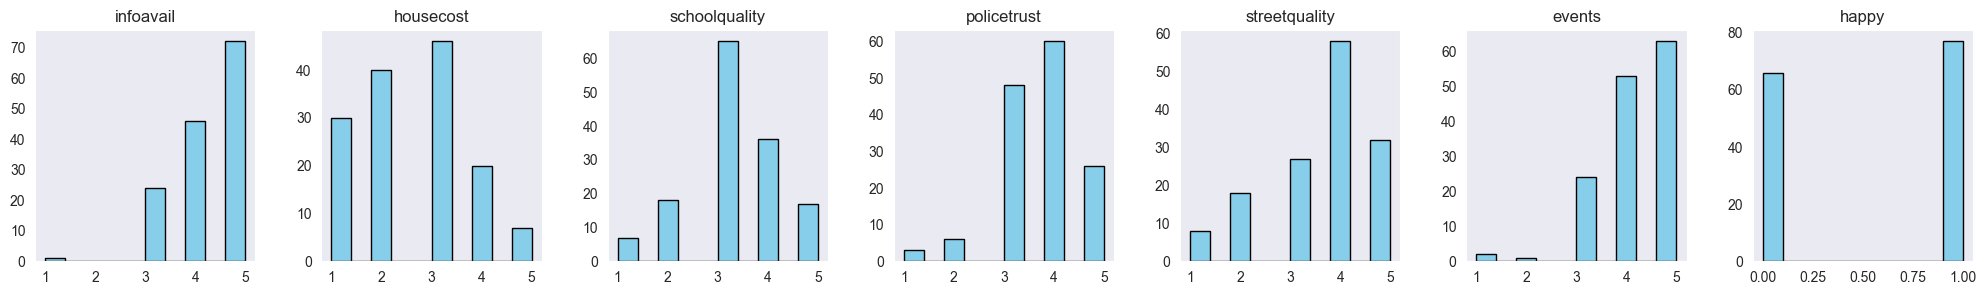

In [4]:
df.hist(
    figsize=(25, 3),
    color='skyblue',
    grid=False,
    edgecolor='black',
    layout=(1, len(df.columns)),
)

Text(0.5, 1.0, 'Correlation Matrix')

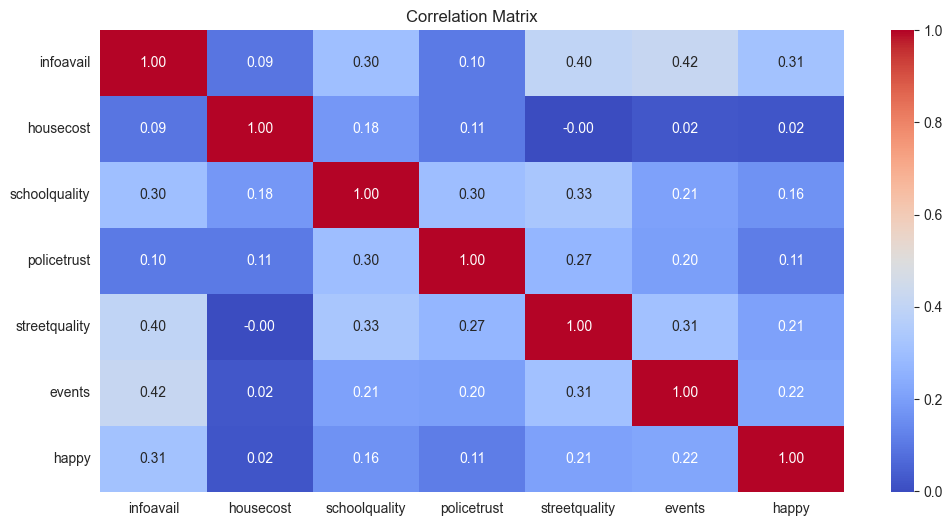

In [5]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('happy', axis=1)
y = df['happy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
from keras.src.optimizers import Adam
from keras.src.callbacks import EarlyStopping
from keras.src.layers import InputLayer, Dense
from keras import Sequential


def train_model(neurons, activation, learning_rate=0.1, epochs=500, batch_size=2):
    model = Sequential()

    model.add(InputLayer(shape=(X_train.shape[1],)))

    for neuron_num in neurons:
        model.add(Dense(neuron_num, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=[early_stopping]
    )

    return model, history

In [14]:
from sklearn.metrics import classification_report, confusion_matrix


def evaluate_model(model, history, model_name):
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n{model_name} - Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

    y_pred = (model.predict(X_test) > 0.5).astype("int32")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()



--- MODEL 1: Simple Network with ReLU Activation ---
Epoch 1/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4560 - loss: 2.0155 - val_accuracy: 0.5517 - val_loss: 0.6883
Epoch 2/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5268 - loss: 0.6956 - val_accuracy: 0.5517 - val_loss: 0.6878
Epoch 3/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5082 - loss: 0.6972 - val_accuracy: 0.5517 - val_loss: 0.6920
Epoch 4/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5927 - loss: 0.6795 - val_accuracy: 0.5517 - val_loss: 0.6910
Epoch 5/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5124 - loss: 0.7039 - val_accuracy: 0.5517 - val_loss: 0.6893
Epoch 6/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5931 - loss: 0.6798 - val_accuracy: 0.5517 - val_loss: 0.6913
Epoch 7/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5414 - loss: 0.6967 - val_accuracy: 0.5517 - val_loss: 0.6903
Epoch 8/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc

C:\uni\ML\ML_6th_sem\lab4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\uni\ML\ML_6th_sem\lab4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\uni\ML\ML_6th_sem\lab4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


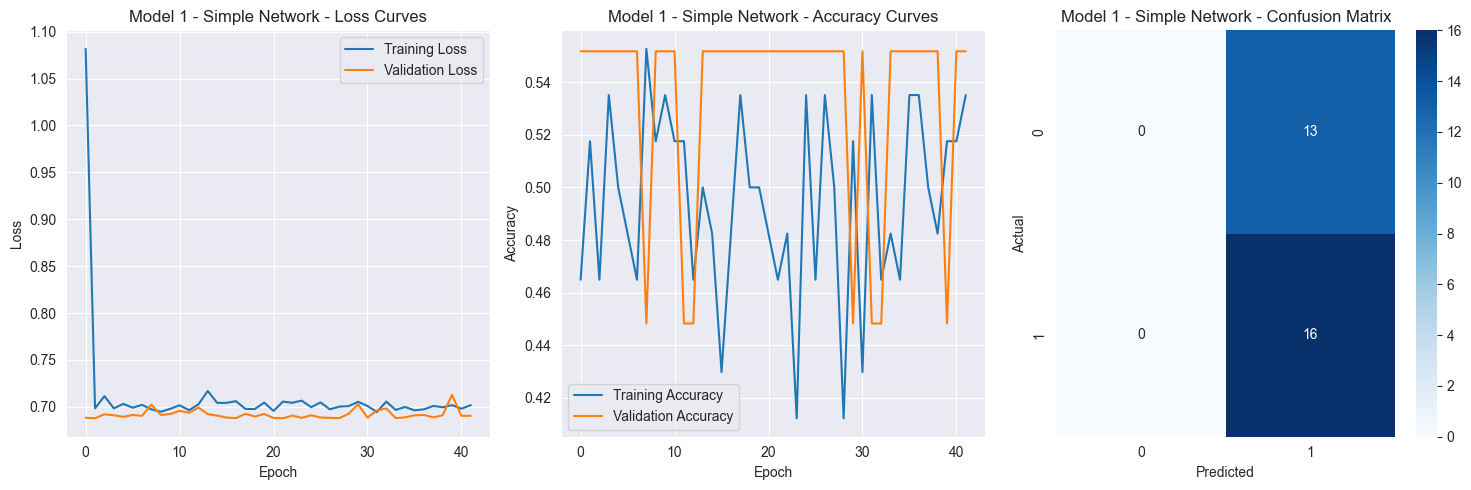

In [16]:
print("\n\n--- MODEL 1: Simple Network with ReLU Activation ---")
model1, history1 = train_model(
    neurons=[30, 25, 15, 8, 4, 2],
    epochs=200,
    learning_rate=0.1,
    activation='relu'
)
evaluate_model(model1, history1, "Model 1 - Simple Network")

In [ ]:
model_names = [
    "Model 1 - Simple Network",
]

models = [model1]
histories = [history1]

In [ ]:
plt.figure(figsize=(12, 8))
for i, history in enumerate(histories):
    plt.plot(history.history['val_accuracy'], label=model_names[i])

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()